# Model Selection & Tuning — Fraud Spike Detector

This notebook documents the reasoning behind decisions already made in `src/train.py` and `src/evaluate.py`. It loads the saved artifacts from those scripts rather than re-running training, so the numbers here are exactly what ended up in production, not a fresh (possibly different) run.

## Why PR-AUC, not accuracy or ROC-AUC

`01_eda.ipynb` established that a classifier which always predicts "not fraud" scores ~99.8% accuracy on this data — so accuracy can't distinguish a good fraud model from a useless one. ROC-AUC is better but still overstates performance under extreme imbalance, because the false-positive *rate* stays tiny even when the false-positive *count* (relative to the fraud count) is large. PR-AUC (average precision) doesn't have this blind spot — it's directly sensitive to how many of the model's fraud flags are correct, which is what actually matters operationally. That's why `src/train.py` selects the winning model on validation PR-AUC, not accuracy or ROC-AUC.

## Why class weighting, not SMOTE or undersampling

Train has only 295 fraud rows. Two alternatives were considered and rejected:
- **SMOTE (synthetic oversampling)** interpolates *new* synthetic fraud points between existing ones. With so few real examples to interpolate between, this risks manufacturing unrealistic points that don't reflect real fraud patterns, and can make validation metrics look better than real-world performance will be.
- **Undersampling** the majority class would throw away legitimate transaction data that the non-fraud class needs in order to be well characterized — with 284k legitimate examples available, there's no data-volume reason to discard any of it.

`class_weight="balanced"` avoids both problems: it keeps the real, unmodified class distribution and just reweights each class's contribution to the training loss so the rare class isn't drowned out.

## Why Decision Tree was skipped from the comparison

Random Forest **is** an ensemble of decision trees (with bagging + feature subsampling per split). A single Decision Tree is strictly a weaker, higher-variance version of what's already being tested — it would predictably underperform Random Forest and wouldn't tell us anything the Random Forest result doesn't already cover. Including it would have padded the comparison without adding information.

## Three-model comparison

Logistic Regression (linear baseline), Random Forest, and HistGradientBoosting were trained on the same `train` split and scored by PR-AUC on the same `val` split. Loading the actual leaderboard `src/train.py` saved, rather than restating the numbers by hand:

In [1]:
import json

with open("../models/model_meta.json") as f:
    meta = json.load(f)

for name, pr_auc in sorted(
    meta["leaderboard"].items(), key=lambda kv: kv[1], reverse=True
):
    marker = "  <- selected" if name == meta["model_name"] else ""
    print(f"{name:<24} val PR-AUC = {pr_auc:.4f}{marker}")

random_forest            val PR-AUC = 0.7994  <- selected
logistic_regression      val PR-AUC = 0.6858
hist_gradient_boosting   val PR-AUC = 0.6837


**Random Forest wins clearly** (0.799 vs. 0.686 for Logistic Regression and 0.684 for HistGradientBoosting). Both LR and HGB land in roughly the same range, for different reasons:
- **Logistic Regression** is linear — it can't capture the non-linear interactions between PCA components that separate fraud from non-fraud here.
- **HistGradientBoosting** is non-linear but was run with untuned defaults (`max_iter=100`, `learning_rate=0.1`); with only 295 positive examples, its boosting rounds and early-stopping default likely converge before fully capturing the minority-class pattern. It fit ~15x faster than Random Forest, so there's tuning headroom if boosting were ever preferred for other reasons (e.g. calibration, model size) — but Random Forest already clears a strong bar without that investment, so it was kept as the selected model rather than spending that effort here.

## Threshold selection (0.30)

PR-AUC ranks models but doesn't hand you an operating threshold — that's a separate decision made **only on validation data**, never on test. `src/train.py` scans the validation precision-recall curve and picks the threshold that maximizes F1 (the precision/recall balance point), since there's no stated business preference for favoring one over the other here.

Reproducing that curve to show *why* 0.30 was chosen, not just what the value is:

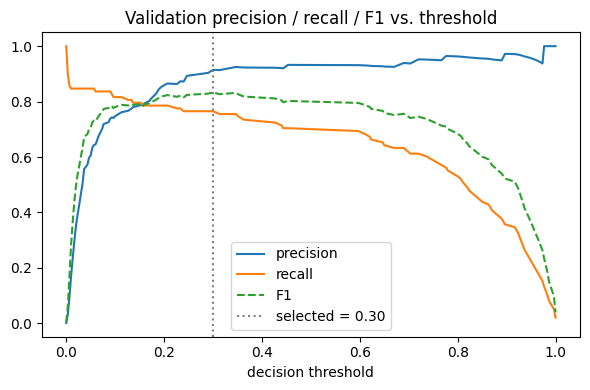

selected threshold: 0.3000
val F1 at that threshold: 0.8333


In [2]:
import joblib
import pandas as pd
from sklearn.metrics import precision_recall_curve

model = joblib.load("../models/model.joblib")
val = pd.read_csv("../data/processed/val_scaled.csv")
X_val, y_val = val[meta["feature_cols"]], val["Class"]

val_scores = model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_scores)
f1 = 2 * precision * recall / (precision + recall + 1e-12)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(thresholds, precision[:-1], label="precision")
plt.plot(thresholds, recall[:-1], label="recall")
plt.plot(thresholds, f1[:-1], label="F1", linestyle="--")
plt.axvline(meta["threshold"], color="gray", linestyle=":", label=f'selected = {meta["threshold"]:.2f}')
plt.xlabel("decision threshold")
plt.legend()
plt.title("Validation precision / recall / F1 vs. threshold")
plt.tight_layout()
plt.show()

print(f'selected threshold: {meta["threshold"]:.4f}')
print(f'val F1 at that threshold: {meta["val_f1_at_threshold"]:.4f}')

0.30 sits below the naive midpoint of 0.5 because `class_weight="balanced"` already shifts the model's raw score distribution — a lower cutoff is where precision and recall actually balance for *this* reweighted model, not an arbitrary choice.

## Final test-set results — one locked run

This is the only time the test set is used. The model and threshold above were both finalized on train/val alone; `src/evaluate.py` then ran that fixed model + threshold against the test set exactly once, with no retuning afterward. Loading its saved output directly:

In [3]:
with open("../results/test_metrics.json") as f:
    test_metrics = json.load(f)

print(f'model:      {test_metrics["model_name"]}')
print(f'threshold:  {test_metrics["threshold"]}')
print(f'PR-AUC:     {test_metrics["test_pr_auc"]:.4f}')
print(f'ROC-AUC:    {test_metrics["test_roc_auc"]:.4f}')
print(f'Precision:  {test_metrics["test_precision"]:.4f}')
print(f'Recall:     {test_metrics["test_recall"]:.4f}')
print(f'F1:         {test_metrics["test_f1"]:.4f}')
print(f'\nconfusion matrix: {test_metrics["confusion_matrix"]}')
print(f'{test_metrics["n_test_fraud"]} actual fraud rows out of {test_metrics["n_test_rows"]:,} test rows')

model:      random_forest
threshold:  0.3
PR-AUC:     0.8760
ROC-AUC:    0.9621
Precision:  0.9529
Recall:     0.8182
F1:         0.8804

confusion matrix: {'true_negative': 56859, 'false_positive': 4, 'false_negative': 18, 'true_positive': 81}
99 actual fraud rows out of 56,962 test rows


**Reading these honestly:** 95.3% precision / 81.8% recall means the model catches roughly 4 out of 5 fraud cases in test, and when it flags something, it's right ~95% of the time (4 false positives out of 56,962 test transactions). The 18 missed fraud cases (false negatives) are the real cost of the chosen threshold — a lower threshold would catch more of them at the price of more false alarms. That tradeoff is exactly what the precision/recall/F1 curve above makes visible, rather than something baked in silently.

For why we can't say *which transaction attributes* drove these predictions beyond numbered PCA components, see the interpretability note in [`01_eda.ipynb`](./01_eda.ipynb) and the SHAP output from `src/explain.py`.